In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler , StandardScaler , OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [58]:
data = pd.read_csv('../../../data/PlayTennis.csv')

data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [59]:
from sklearn.preprocessing import OrdinalEncoder

Outlook_encoder = OrdinalEncoder()
data['Outlook'] = Outlook_encoder.fit_transform(data[['Outlook']])

data

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,Hot,High,Weak,No
1,2.0,Hot,High,Strong,No
2,0.0,Hot,High,Weak,Yes
3,1.0,Mild,High,Weak,Yes
4,1.0,Cool,Normal,Weak,Yes
5,1.0,Cool,Normal,Strong,No
6,0.0,Cool,Normal,Strong,Yes
7,2.0,Mild,High,Weak,No
8,2.0,Cool,Normal,Weak,Yes
9,1.0,Mild,Normal,Weak,Yes


In [60]:
Temperature_encoder = OrdinalEncoder()
data['Temperature'] = Temperature_encoder.fit_transform(data[['Temperature']])

In [61]:
Humidity_encoder = OrdinalEncoder()
data['Humidity'] = Humidity_encoder.fit_transform(data[['Humidity']])

In [62]:
Wind_encoder = OrdinalEncoder()
data['Wind'] = Wind_encoder.fit_transform(data[['Wind']])

In [63]:
Tennis_encoder = OrdinalEncoder()
data['Play Tennis'] = Tennis_encoder.fit_transform(data[['Play Tennis']])

In [64]:
data

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,1.0,0.0
1,2.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0
3,1.0,2.0,0.0,1.0,1.0
4,1.0,0.0,1.0,1.0,1.0
5,1.0,0.0,1.0,0.0,0.0
6,0.0,0.0,1.0,0.0,1.0
7,2.0,2.0,0.0,1.0,0.0
8,2.0,0.0,1.0,1.0,1.0
9,1.0,2.0,1.0,1.0,1.0


In [65]:
x = data.drop(["Play Tennis"] , axis=1)
y = data['Play Tennis']

x.head()

y.head()

0    0.0
1    0.0
2    1.0
3    1.0
4    1.0
Name: Play Tennis, dtype: float64

In [66]:
x_train, x_test , y_train , y_test = train_test_split(x , y , random_state=42 , test_size=0.2)

In [67]:
clf = DecisionTreeClassifier(criterion='gini' , random_state=42)

clf.fit(x_train , y_train)

y_pred = clf.predict(x_test)

In [68]:
clf_entropy = DecisionTreeClassifier(criterion='entropy' , random_state=42)

clf_entropy.fit(x_train , y_train)

y_pred_entropy = clf_entropy.predict(x_test)

In [69]:
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix

In [70]:
print('Accuracy\n',accuracy_score(y_test , y_pred) , 'With GINI')
print('-'*20)
print('classification_report\n',classification_report(y_test , y_pred) , 'With GINI')
print('-'*20)
print('confusion_matrix\n',confusion_matrix(y_test , y_pred) , 'With GINI')




Accuracy
 1.0 With GINI
--------------------
classification_report
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3
 With GINI
--------------------
confusion_matrix
 [[1 0]
 [0 2]] With GINI


In [71]:
print('Accuracy\n',accuracy_score(y_test , y_pred_entropy) , 'With ENTROPY')
print('-'*20)
print('classification_report\n',classification_report(y_test , y_pred_entropy) , 'With ENTROPY')
print('-'*20)
print('confusion_matrix\n',confusion_matrix(y_test , y_pred_entropy) , 'With ENTROPY')

Accuracy
 1.0 With ENTROPY
--------------------
classification_report
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3
 With ENTROPY
--------------------
confusion_matrix
 [[1 0]
 [0 2]] With ENTROPY


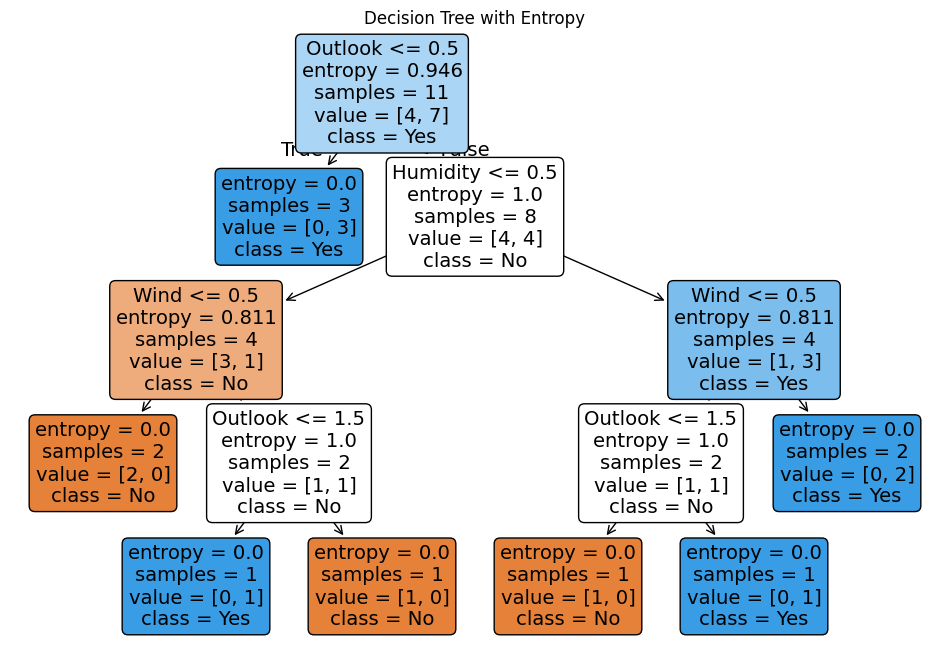

In [72]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf_entropy , filled=True , feature_names=x.columns , class_names=Tennis_encoder.categories_[0] , rounded=True)
plt.title('Decision Tree with Entropy')
plt.show()